# Data Preprocessing

### Workflow
- Import Required Libraries
- Load Dataset
- Separate Features and Target Variable
- Combine Train and Test Dataset
- Handle Missing Values
- Handle Outliers
- Feature Engineering
- Encode Features & Feature Scaling
- Save Processed Dataset

## Load Dataset & Separate Features 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.reset_option('display.max_columns',None)
pd.reset_option('display.max_rows',None)
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
train_df = pd.read_csv("../dataset/raw/train.csv")
test_df = pd.read_csv("../dataset/raw/test.csv")

In [4]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
# separate Features and target
X = train_df.drop("SalePrice",axis=1)
y = train_df['SalePrice']

In [7]:
# Combine train, test data for data preprocessing
df = pd.concat([X,test_df], axis=0 , ignore_index=True)

In [8]:
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2673,2674,120,RM,NaN,3072,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Normal
1882,1883,60,RL,70.0,8749,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2009,WD,Normal
1715,1716,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2009,WD,Normal
585,586,20,RL,88.0,11443,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2006,New,Partial
630,631,70,RM,50.0,9000,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2006,WD,Abnorml


In [9]:
df.shape

(2919, 80)

In [10]:
df.dtypes.value_counts()

object     43
int64      26
float64    11
Name: count, dtype: int64

## Handle Missing Values

In [11]:
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols>0]

In [12]:
missing_cols

MSZoning           4
LotFrontage      486
Alley           2721
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType      1766
MasVnrArea        23
BsmtQual          81
BsmtCond          82
BsmtExposure      82
BsmtFinType1      79
BsmtFinSF1         1
BsmtFinType2      80
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu     1420
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2909
Fence           2348
MiscFeature     2814
SaleType           1
dtype: int64

In [13]:
missing_cols.dtypes

dtype('int64')

In [14]:
# percentages 
missing_cols_p = df.isna().sum()/len(df) 
missing_cols_p = missing_cols_p[missing_cols_p>0]
missing_cols_p

MSZoning        0.001370
LotFrontage     0.166495
Alley           0.932169
Utilities       0.000685
Exterior1st     0.000343
Exterior2nd     0.000343
MasVnrType      0.605002
MasVnrArea      0.007879
BsmtQual        0.027749
BsmtCond        0.028092
BsmtExposure    0.028092
BsmtFinType1    0.027064
BsmtFinSF1      0.000343
BsmtFinType2    0.027407
BsmtFinSF2      0.000343
BsmtUnfSF       0.000343
TotalBsmtSF     0.000343
Electrical      0.000343
BsmtFullBath    0.000685
BsmtHalfBath    0.000685
KitchenQual     0.000343
Functional      0.000685
FireplaceQu     0.486468
GarageType      0.053786
GarageYrBlt     0.054471
GarageFinish    0.054471
GarageCars      0.000343
GarageArea      0.000343
GarageQual      0.054471
GarageCond      0.054471
PoolQC          0.996574
Fence           0.804385
MiscFeature     0.964029
SaleType        0.000343
dtype: float64

In [15]:
missing_cols_p[missing_cols_p < 0.01]

MSZoning        0.001370
Utilities       0.000685
Exterior1st     0.000343
Exterior2nd     0.000343
MasVnrArea      0.007879
BsmtFinSF1      0.000343
BsmtFinSF2      0.000343
BsmtUnfSF       0.000343
TotalBsmtSF     0.000343
Electrical      0.000343
BsmtFullBath    0.000685
BsmtHalfBath    0.000685
KitchenQual     0.000343
Functional      0.000685
GarageCars      0.000343
GarageArea      0.000343
SaleType        0.000343
dtype: float64

In [16]:
# separate numeric and categorical columns 
missing = df.isna().sum()
missing = missing[missing > 0]
missing_cols = missing.index

num_missing_cols = df[missing_cols].select_dtypes(include='number').columns.tolist()
cat_missing_cols = df[missing_cols].select_dtypes(include='object').columns.tolist()

In [17]:
num_missing_cols 

['LotFrontage',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea']

In [18]:
cat_missing_cols

['MSZoning',
 'Alley',
 'Utilities',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType']

In [19]:
df[cat_missing_cols].T

,0,1,2,3,4,5,6,7,8,9,...,2909,2910,2911,2912,2913,2914,2915,2916,2917,2918
MSZoning,RL,RL,RL,RL,RL,RL,RL,RL,RM,RL,...,RM,RM,RL,RM,RM,RM,RM,RL,RL,RL
Alley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,...,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub,AllPub
Exterior1st,VinylSd,MetalSd,VinylSd,Wd Sdng,VinylSd,VinylSd,VinylSd,HdBoard,BrkFace,MetalSd,...,CemntBd,CemntBd,Plywood,CemntBd,CemntBd,CemntBd,CemntBd,VinylSd,HdBoard,HdBoard
Exterior2nd,VinylSd,MetalSd,VinylSd,Wd Shng,VinylSd,VinylSd,VinylSd,HdBoard,Wd Shng,MetalSd,...,CmentBd,CmentBd,Plywood,CmentBd,CmentBd,CmentBd,CmentBd,VinylSd,Wd Shng,HdBoard
MasVnrType,BrkFace,NaN,BrkFace,NaN,BrkFace,NaN,Stone,Stone,NaN,NaN,...,NaN,NaN,BrkFace,NaN,NaN,NaN,NaN,NaN,NaN,BrkFace
BsmtQual,Gd,Gd,Gd,TA,Gd,Gd,Ex,Gd,TA,TA,...,Gd,TA,TA,TA,TA,TA,TA,TA,Gd,Gd
BsmtCond,TA,TA,TA,Gd,TA,TA,TA,TA,TA,TA,...,TA,TA,TA,TA,TA,TA,TA,TA,TA,TA
BsmtExposure,No,Gd,Mn,No,Av,No,Av,Mn,No,No,...,Av,No,Av,No,No,No,No,No,Av,Av
BsmtFinType1,GLQ,ALQ,GLQ,ALQ,GLQ,GLQ,GLQ,ALQ,Unf,GLQ,...,GLQ,Rec,Rec,Rec,Unf,Unf,Rec,ALQ,GLQ,LwQ


In [20]:
df[num_missing_cols]

,LotFrontage,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath,GarageYrBlt,GarageCars,GarageArea
0,65.0,196.0,706.0,0.0,150.0,856.0,1.0,0.0,2003.0,2.0,548.0
1,80.0,0.0,978.0,0.0,284.0,1262.0,0.0,1.0,1976.0,2.0,460.0
2,68.0,162.0,486.0,0.0,434.0,920.0,1.0,0.0,2001.0,2.0,608.0
3,60.0,0.0,216.0,0.0,540.0,756.0,1.0,0.0,1998.0,3.0,642.0
4,84.0,350.0,655.0,0.0,490.0,1145.0,1.0,0.0,2000.0,3.0,836.0
...,...,...,...,...,...,...,...,...,...,...,...
2914,21.0,0.0,0.0,0.0,546.0,546.0,0.0,0.0,NaN,0.0,0.0
2915,21.0,0.0,252.0,0.0,294.0,546.0,0.0,0.0,1970.0,1.0,286.0
2916,160.0,0.0,1224.0,0.0,0.0,1224.0,1.0,0.0,1960.0,2.0,576.0
2917,62.0,0.0,337.0,0.0,575.0,912.0,0.0,1.0,NaN,0.0,0.0


In [21]:
for col in num_missing_cols:
    df[col] = df[col].fillna(df[col].median())

In [22]:
for col in cat_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
print(df[missing_cols].isna().sum())

MSZoning        0
LotFrontage     0
Alley           0
Utilities       0
Exterior1st     0
Exterior2nd     0
MasVnrType      0
MasVnrArea      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinSF1      0
BsmtFinType2    0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
Electrical      0
BsmtFullBath    0
BsmtHalfBath    0
KitchenQual     0
Functional      0
FireplaceQu     0
GarageType      0
GarageYrBlt     0
GarageFinish    0
GarageCars      0
GarageArea      0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
SaleType        0
dtype: int64


## Handling Outliers


In [24]:
num_cols = df.select_dtypes(include='number').columns.tolist()

# Remove Id (not a predictive feature)
num_cols.remove('Id')
num_cols.remove('MSSubClass')

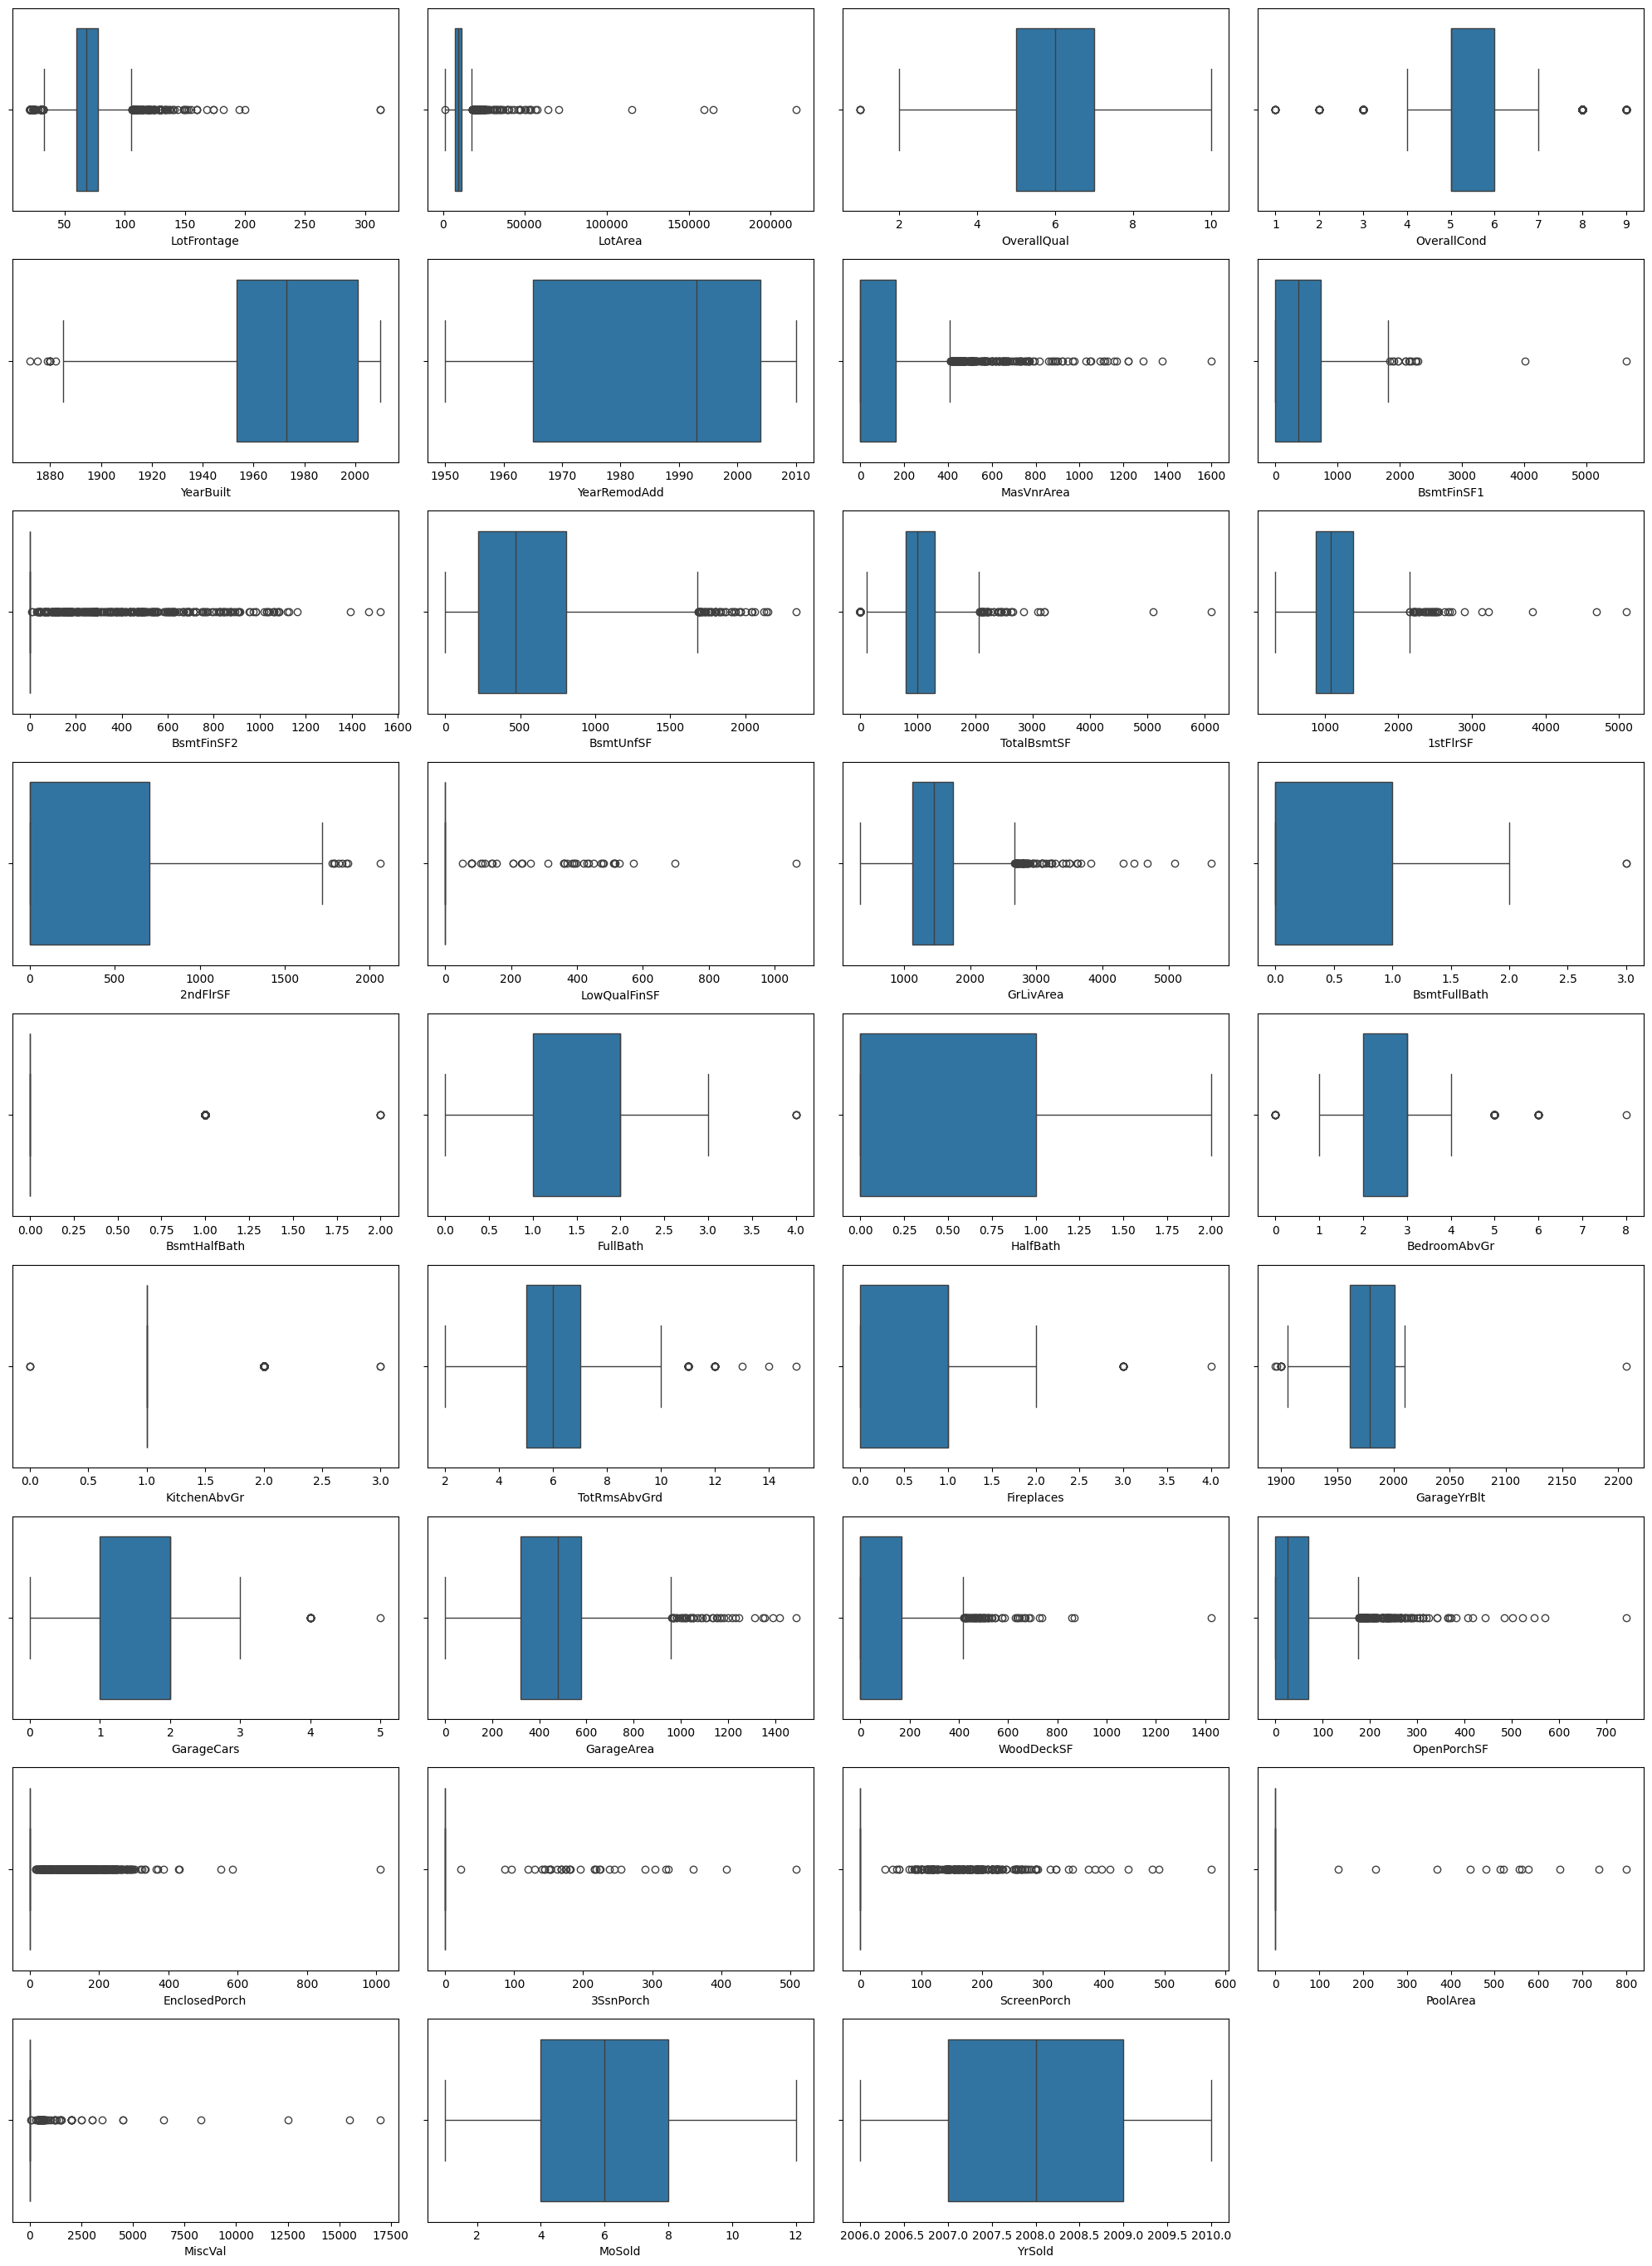

In [25]:
# Visualize outlier
plt.figure(figsize=(20,30))

for i, col in enumerate(num_cols):
    plt.subplot(10,4,i+1)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

In [26]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

pd.Series(outlier_summary).sort_values(ascending=False)

EnclosedPorch    459
BsmtFinSF2       347
LotFrontage      260
ScreenPorch      256
OverallCond      252
MasVnrArea       202
BsmtHalfBath     175
OpenPorchSF      159
KitchenAbvGr     134
LotArea          128
TotalBsmtSF      122
MiscVal          103
BedroomAbvGr      78
GrLivArea         74
WoodDeckSF        67
BsmtUnfSF         53
TotRmsAbvGrd      51
1stFlrSF          42
GarageArea        42
LowQualFinSF      40
3SsnPorch         37
GarageCars        17
BsmtFinSF1        15
PoolArea          13
Fireplaces        12
YearBuilt          9
GarageYrBlt        9
2ndFlrSF           8
FullBath           4
OverallQual        4
BsmtFullBath       2
HalfBath           0
YearRemodAdd       0
MoSold             0
YrSold             0
dtype: int64

### Outlier Analysis

Potential outliers were detected using the IQR method. No outliers were removed, as they appear to represent valid property characteristics rather than erroneous data. Retaining these observations preserves important information and maintains the original data distribution for model training.

## Feature Engineering

In [27]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

#### 1. House Age
- older houses may have different prices than newer one

In [28]:
df['HouseAge'] = df["YrSold"] - df["YearBuilt"]

#### 2. House Remodeling

In [29]:
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

#### 3. Total living area

In [30]:
df['TotalSF']= (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

#### 4. Total Bathrooms

In [32]:
df["TotalBath"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
)

#### 5. Total Porch Area

In [33]:
df["TotalPorchSF"] = (
    df["OpenPorchSF"] +
    df["EnclosedPorch"] +
    df["3SsnPorch"] +
    df["ScreenPorch"]
)

#### 6. Has Garage

In [34]:
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)

#### 7. Has Basement

In [35]:
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

#### 8. Has Fireplace

In [36]:
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

#### 9. Has Pool

In [37]:
df["HasPool"] = (df["PoolArea"] > 0).astype(int)

## Encode Features & Feature Scaling

In [44]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [45]:
# Numerical columns
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
cat_features = df.select_dtypes(include=["object"]).columns.tolist()

In [46]:
print(num_features)
print("\n",cat_features)

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HasGarage', 'HasBasement', 'HasFireplace', 'HasPool']

 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',

In [47]:
# ordinal features
ordinal_features = [
    "LotShape",
    "Utilities",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "Electrical",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "Fence"
]

In [48]:
# nominal features
nominal_features = [
    col for col in cat_features
    if col not in ordinal_features
]

#### Ordinal Encoding

In [55]:
quality = ["Po", "Fa", "TA", "Gd", "Ex"]

bsmt_exposure = [
    "No",
    "Mn",
    "Av",
    "Gd"
]

bsmt_fin_type = [
    "Unf",
    "LwQ",
    "Rec",
    "BLQ",
    "ALQ",
    "GLQ"
]

garage_finish = [
    "Unf",
    "RFn",
    "Fin"
]

paved_drive = [
    "N",
    "P",
    "Y"
]

fence = [
    "MnWw",
    "GdWo",
    "MnPrv",
    "GdPrv"
]

functional = [
    "Sal",
    "Sev",
    "Maj2",
    "Maj1",
    "Mod",
    "Min2",
    "Min1",
    "Typ"
]

electrical = [
    "Mix",
    "FuseP",
    "FuseF",
    "FuseA",
    "SBrkr"
]

In [56]:
categories = [
    ["IR3", "IR2", "IR1", "Reg"],           
    ["ELO", "NoSeWa", "NoSewr", "AllPub"],  
    ["Sev", "Mod", "Gtl"],                  
    quality,                                 
    quality,                                 
    quality,                                
    quality,                                
    bsmt_exposure,                          
    bsmt_fin_type,                          
    bsmt_fin_type,                           
    quality,                                 
    electrical,                              
    quality,                                 
    functional,                              
    quality,                                 
    garage_finish,                           
    quality,                                
    quality,                                 
    paved_drive,                             
    quality,                                 
    fence                                    
]

In [57]:
ordinal_encoder = OrdinalEncoder(
    categories=categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

#### One-Hot Encoder

In [58]:
nominal_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

#### Standard Scaler

In [59]:
scaler = StandardScaler()

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, num_features),
        ("ord", ordinal_encoder, ordinal_features),
        ("nom", nominal_encoder, nominal_features)
    ]
)

In [61]:
X_processed = preprocessor.fit_transform(df)

In [65]:
type(X_processed), X_processed.shape

(numpy.ndarray, (2919, 227))

In [66]:
feature_names = preprocessor.get_feature_names_out()

df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=df.index
)

df.head()

,num__Id,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,...,nom__SaleType_ConLw,nom__SaleType_New,nom__SaleType_Oth,nom__SaleType_WD,nom__SaleCondition_Abnorml,nom__SaleCondition_AdjLand,nom__SaleCondition_Alloca,nom__SaleCondition_Family,nom__SaleCondition_Normal,nom__SaleCondition_Partial
0,-1.731458,0.067331,-0.191815,-0.217879,0.646183,-0.507284,1.046258,0.896833,0.529034,0.580959,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.730271,-0.873616,0.511940,-0.072044,-0.063185,2.188279,0.154764,-0.395604,-0.567016,1.178162,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.729084,0.067331,-0.051064,0.137197,0.646183,-0.507284,0.980221,0.848965,0.338903,0.097928,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.727897,0.302568,-0.426400,-0.078385,0.646183,-0.507284,-1.859351,-0.682812,-0.567016,-0.494884,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.726711,0.067331,0.699608,0.518903,1.355551,-0.507284,0.947203,0.753229,1.390216,0.468984,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Columns: 227 entries, num__Id to nom__SaleCondition_Partial
dtypes: float64(227)
memory usage: 5.1 MB


## Save Processed data

In [69]:
train_processed = df.iloc[:len(train_df)].copy()
test_processed = df.iloc[len(train_df):].copy()

In [70]:
train_processed["SalePrice"] = y.values

In [71]:
train_processed.shape, test_processed.shape

((1460, 228), (1459, 227))

In [73]:
feature_names = pd.DataFrame({
    "Feature_Name": train_processed.drop(columns="SalePrice").columns
})

feature_names.to_csv("../dataset/processed-data/feature_names.csv", index=False)

In [74]:
train_processed.to_csv("../dataset/processed-data/train.csv", index=False)
test_processed.to_csv("../dataset/processed-data/test.csv", index=False)